# Fully Nested CV — Results

Plots for `run_nested_experiment_full` (model_hpc.py): feature type, ranking function,
`top_genes` and the SVM hyperparameters are all chosen **inside** each outer fold, on
data-driven TSS features only.

Each outer fold's held-out AUC comes from a configuration selected without ever seeing
that fold, so the mean across folds estimates the **selection procedure**, not one
hand-picked configuration.

Run from the repository root.

In [18]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Point this at the run you want to plot.
#   .../nested_full_brca_crc_nested_full        <- the full run
#   .../nested_full_brca_crc_nested_full_test   <- the reduced correctness run
RESULTS_DIR = Path("nested_cv_results_cris/nested_full_brca_crc_nested_full")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# One colour per data-driven feature, reused across every plot below.
FEATURE_COLORS = {
    "griffin_diff":  "#4C72B0",
    "rcov":          "#DD8452",
    "mwh":           "#55A868",
    "fslr":          "#C44E52",
    "fslr_coverage": "#8172B3",
}
RANKING_COLORS = {
    "mean_diff":   "#4C72B0",
    "p_value":     "#DD8452",
    "fold_change": "#55A868",
    "weighted":    "#C44E52",
}

In [19]:
if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"{RESULTS_DIR} not found. Run the experiment first:\n"
        f"    ./submit_nested_full.sh test    # reduced correctness run\n"
        f"    ./submit_nested_full.sh full    # the real run"
    )

with open(RESULTS_DIR / "nested_full_per_fold.pkl", "rb") as fh:
    per_fold = pickle.load(fh)

oof = pd.read_csv(RESULTS_DIR / "nested_full_oof_predictions.csv")

with open(RESULTS_DIR / "nested_full_summary.json") as fh:
    summary = json.load(fh)

with open(RESULTS_DIR / "nested_full_selected_indices.pkl", "rb") as fh:
    selected_indices = pickle.load(fh)

aucs = per_fold["test_auc"].to_numpy(dtype=float)

print(f"folds            : {len(per_fold)}")
print(f"samples (OOF)    : {len(oof)}  (unique: {oof['sample_id'].nunique()})")
print(f"features searched: {summary['features_searched']}")
print(f"ranking searched : {summary['selection_types_searched']}")
print(f"k searched       : {summary['top_genes_searched']}")
print(f"classifiers      : {summary['classifiers_searched']}")
print()
print(f"held-out AUC     : mean {aucs.mean():.4f}  sd {aucs.std(ddof=1):.4f} "
      f"(min {aucs.min():.4f}, max {aucs.max():.4f})")
print(f"pooled OOF AUC   : {summary['oof_auc_pooled']:.4f}")

per_fold[["fold", "feature", "selection_type", "n_top_genes",
          "classifier", "inner_best_score", "test_auc"]]

folds            : 10
samples (OOF)    : 290  (unique: 290)
features searched: ['fslr_coverage', 'fslr', 'griffin_diff', 'rcov', 'mwh']
ranking searched : ['mean_diff', 'fold_change']
k searched       : [10, 25, 50, 100, 250, 500, 1000, 1500, 2500, 5000, 10000, 15000]
classifiers      : ['Support Vector Machine']

held-out AUC     : mean 0.9506  sd 0.0407 (min 0.8929, max 0.9940)
pooled OOF AUC   : 0.9502


,fold,feature,selection_type,n_top_genes,classifier,inner_best_score,test_auc
0,1,griffin_diff,mean_diff,15000,Support Vector Machine,0.937169,0.994048
1,2,griffin_diff,mean_diff,15000,Support Vector Machine,0.947751,0.994048
2,3,griffin_diff,mean_diff,15000,Support Vector Machine,0.951279,0.898810
3,4,griffin_diff,mean_diff,15000,Support Vector Machine,0.935185,0.988095
4,5,griffin_diff,mean_diff,15000,Support Vector Machine,0.953924,0.934524
5,6,griffin_diff,mean_diff,15000,Support Vector Machine,0.940256,0.892857
6,7,griffin_diff,mean_diff,15000,Support Vector Machine,0.937169,0.976190
7,8,griffin_diff,mean_diff,15000,Support Vector Machine,0.938933,0.976190
8,9,griffin_diff,mean_diff,15000,Support Vector Machine,0.950617,0.904762
9,10,griffin_diff,mean_diff,15000,Support Vector Machine,0.946429,0.946429


## 1. Per-fold held-out AUC

The inner (selection) score sits next to the held-out score for each fold. A large gap
between them is the winner's curse the nesting is there to remove: the inner score is a
maximum over the grid, the held-out score is not.

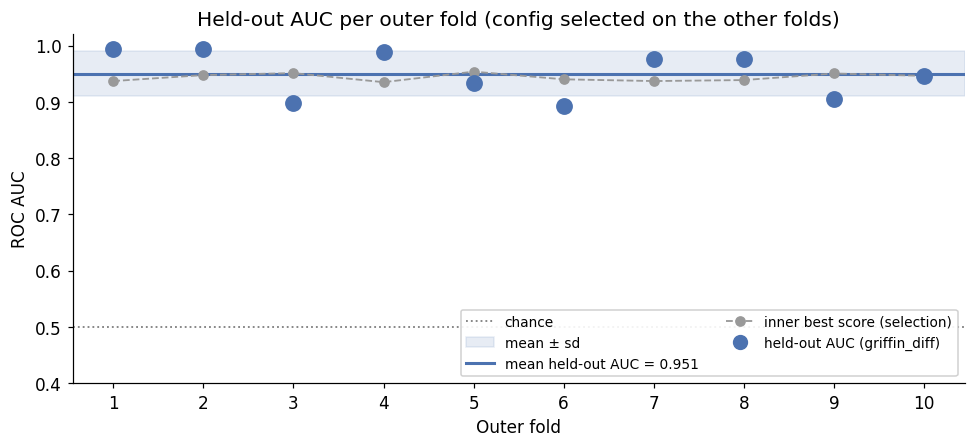

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = per_fold["fold"].to_numpy()

ax.axhline(0.5, color="grey", ls=":", lw=1.2, label="chance")
ax.axhspan(aucs.mean() - aucs.std(ddof=1), aucs.mean() + aucs.std(ddof=1),
           color="#4C72B0", alpha=0.13, label=f"mean ± sd")
ax.axhline(aucs.mean(), color="#4C72B0", lw=2,
           label=f"mean held-out AUC = {aucs.mean():.3f}")

ax.plot(x, per_fold["inner_best_score"], "o--", color="#999999", ms=6,
        lw=1.2, label="inner best score (selection)")
for xi, feat, a in zip(x, per_fold["feature"], aucs):
    ax.plot(xi, a, "o", ms=10, color=FEATURE_COLORS.get(feat, "#333333"), zorder=5)

# Legend entry per feature actually selected
for feat in per_fold["feature"].unique():
    ax.plot([], [], "o", ms=9, color=FEATURE_COLORS.get(feat, "#333333"),
            label=f"held-out AUC ({feat})")

ax.set_xticks(x)
ax.set_xlabel("Outer fold")
ax.set_ylabel("ROC AUC")
ax.set_ylim(0.4, 1.02)
ax.set_title("Held-out AUC per outer fold (config selected on the other folds)")
ax.legend(fontsize=9, loc="lower right", ncol=2, framealpha=0.9)
plt.tight_layout()
plt.show()

## 2. ROC curves

Left: one ROC per outer fold, each from that fold's own selected configuration, plus the
vertically-averaged mean ROC. Right: the pooled out-of-fold ROC — every sample scored
exactly once, by the model of the fold that held it out.

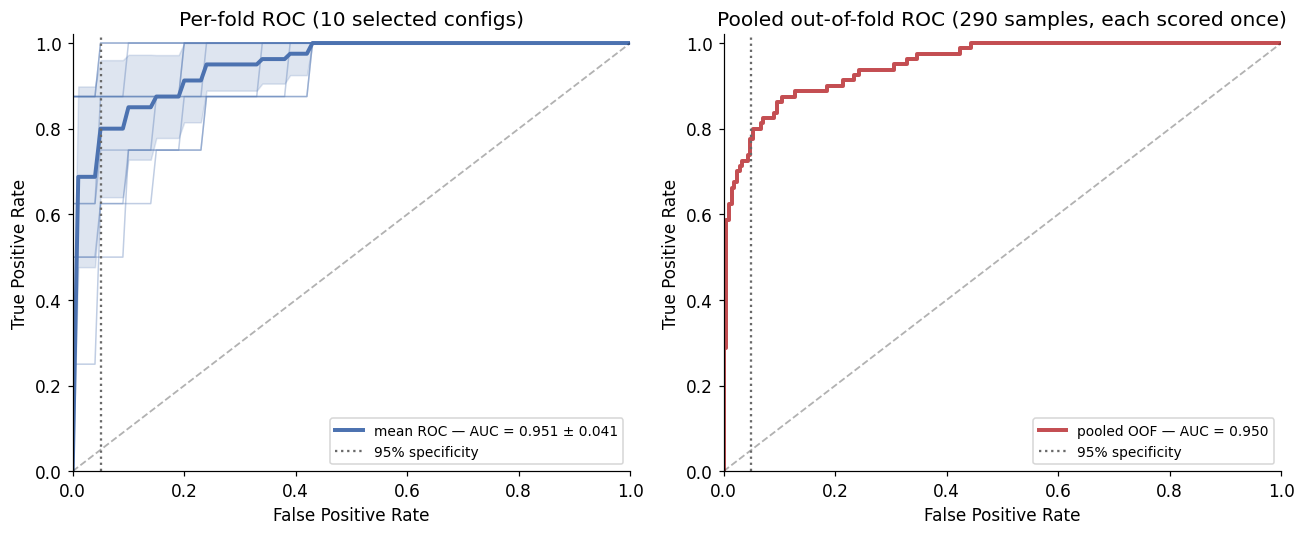

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
base_fpr = np.linspace(0, 1, 101)

tprs = []
for _, row in per_fold.iterrows():
    f = interp1d(row["fpr_full_model"], row["tpr_full_model"], kind="linear")
    t = f(base_fpr)
    tprs.append(t)
    ax1.plot(base_fpr, t, lw=1, alpha=0.35,
             color=FEATURE_COLORS.get(row["feature"], "#333333"))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[0], mean_tpr[-1] = 0, 1
std_tpr = np.std(tprs, axis=0)
ax1.plot(base_fpr, mean_tpr, color="#4C72B0", lw=2.6,
         label=f"mean ROC — AUC = {aucs.mean():.3f} ± {aucs.std(ddof=1):.3f}")
ax1.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                 np.minimum(mean_tpr + std_tpr, 1), color="#4C72B0", alpha=0.18)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, lw=1.2)
ax1.axvline(0.05, color="dimgray", ls=":", lw=1.5, label="95% specificity")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("Per-fold ROC (10 selected configs)")
ax1.legend(loc="lower right", fontsize=9)

fpr_p, tpr_p, _ = roc_curve(oof["y_true"], oof["y_pred_proba"])
ax2.plot(fpr_p, tpr_p, color="#C44E52", lw=2.6,
         label=f"pooled OOF — AUC = {auc(fpr_p, tpr_p):.3f}")
ax2.plot([0, 1], [0, 1], "k--", alpha=0.3, lw=1.2)
ax2.axvline(0.05, color="dimgray", ls=":", lw=1.5, label="95% specificity")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title(f"Pooled out-of-fold ROC ({len(oof)} samples, each scored once)")
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Selection stability

How often each feature, ranking function and `k` was chosen across the ten folds. If one
configuration wins every fold the procedure is stable; a spread means the choice is
driven by fold-level noise and no single configuration is well identified.

Distinct configurations across 10 folds: 1  (UNANIMOUS)

     feature selection_type  n_top_genes             classifier  n_folds
griffin_diff      mean_diff        15000 Support Vector Machine       10


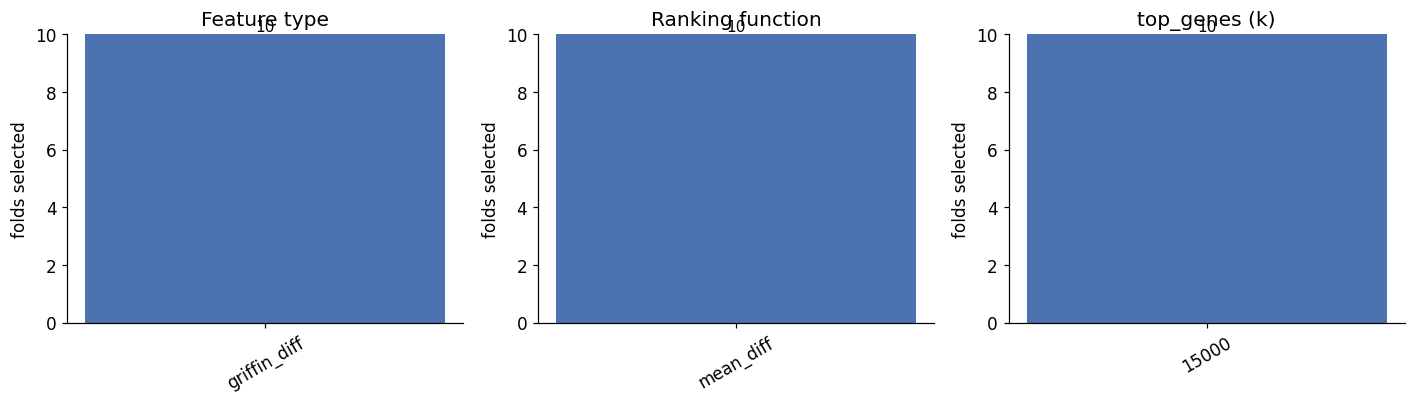

In [22]:
cfg_cols = ["feature", "selection_type", "n_top_genes", "classifier"]
distinct = per_fold[cfg_cols].drop_duplicates()
print(f"Distinct configurations across {len(per_fold)} folds: {len(distinct)}"
      f"{'  (UNANIMOUS)' if len(distinct) == 1 else ''}\n")
print(per_fold.groupby(cfg_cols).size().reset_index(name="n_folds")
      .sort_values("n_folds", ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, colors, title in [
    (axes[0], "feature", FEATURE_COLORS, "Feature type"),
    (axes[1], "selection_type", RANKING_COLORS, "Ranking function"),
    (axes[2], "n_top_genes", None, "top_genes (k)"),
]:
    counts = per_fold[col].value_counts().sort_index()
    cols = [colors.get(str(i), "#4C72B0") for i in counts.index] if colors else "#4C72B0"
    ax.bar([str(i) for i in counts.index], counts.values, color=cols)
    ax.set_title(title)
    ax.set_ylabel("folds selected")
    ax.set_ylim(0, len(per_fold))
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.1, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 4. How close was the feature race?

Each outer fold scores every feature with its own inner GridSearchCV, then keeps the best.
This shows those inner scores. Features separated by a hair mean the winner is close to
arbitrary; a clear leader means the choice is real.

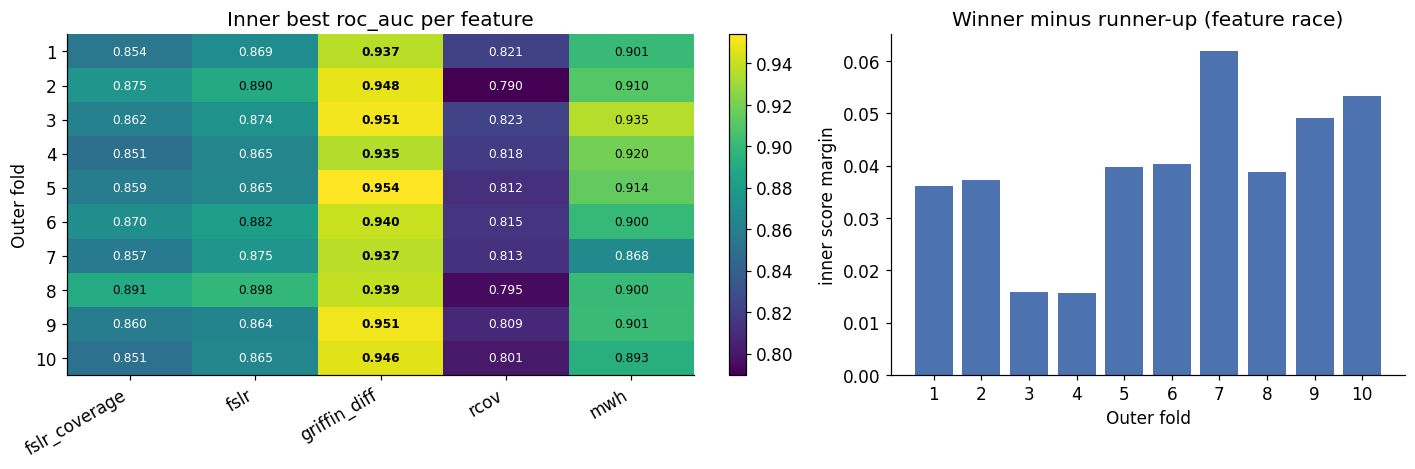

In [23]:
inner = pd.DataFrame(list(per_fold["inner_best_score_per_feature"]),
                     index=per_fold["fold"])
inner = inner[[c for c in summary["features_searched"] if c in inner.columns]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4),
                               gridspec_kw={"width_ratios": [1.35, 1]})

im = ax1.imshow(inner.to_numpy(), aspect="auto", cmap="viridis")
ax1.set_xticks(range(inner.shape[1]))
ax1.set_xticklabels(inner.columns, rotation=30, ha="right")
ax1.set_yticks(range(len(inner)))
ax1.set_yticklabels(inner.index)
ax1.set_ylabel("Outer fold")
ax1.set_title("Inner best roc_auc per feature")
for i in range(inner.shape[0]):
    best_j = int(np.argmax(inner.to_numpy()[i]))
    for j in range(inner.shape[1]):
        v = inner.to_numpy()[i, j]
        ax1.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                 color="white" if v < inner.to_numpy().mean() else "black",
                 fontweight="bold" if j == best_j else "normal")
plt.colorbar(im, ax=ax1, fraction=0.046)

# Margin between the winner and the runner-up, per fold
vals = np.sort(inner.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2] if inner.shape[1] > 1 else np.zeros(len(inner))
ax2.bar(inner.index, margin, color="#4C72B0")
ax2.set_xlabel("Outer fold"); ax2.set_ylabel("inner score margin")
ax2.set_title("Winner minus runner-up (feature race)")
ax2.set_xticks(inner.index)
plt.tight_layout()
plt.show()

## 5. Out-of-fold score distributions

Every sample appears exactly once, scored by the fold that held it out. Split by true
label and by cancer type, so a type that the model systematically misses is visible.

C:\Users\ibpronk\AppData\Local\Temp\ipykernel_18184\2217783786.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([g[1] for g in groups], labels=[g[0] for g in groups],
C:\Users\ibpronk\AppData\Local\Temp\ipykernel_18184\2217783786.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=order, widths=0.55, showfliers=False)


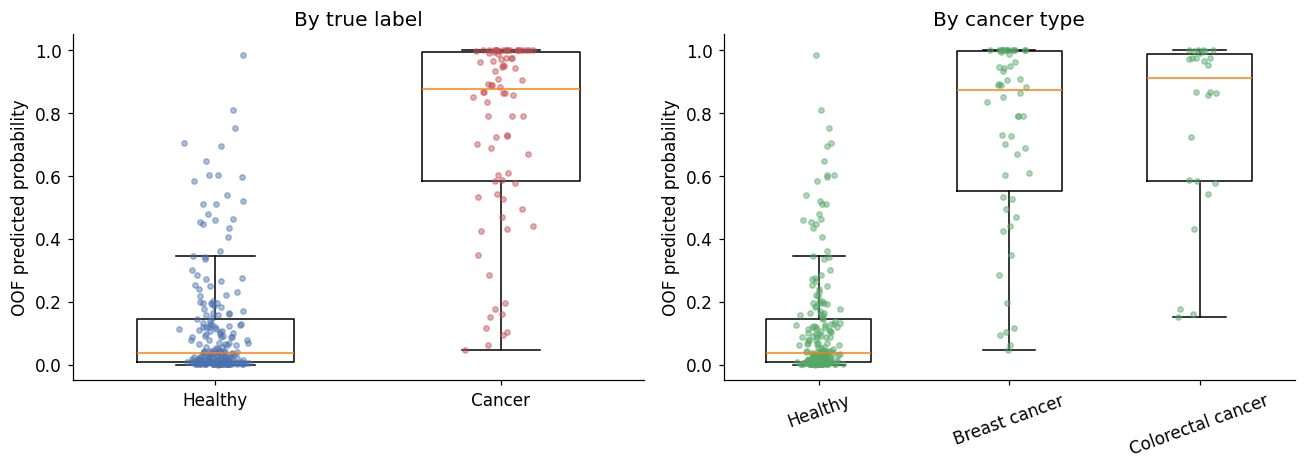

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

groups = [("Healthy", oof.loc[oof["y_true"] == 0, "y_pred_proba"]),
          ("Cancer", oof.loc[oof["y_true"] == 1, "y_pred_proba"])]
ax1.boxplot([g[1] for g in groups], labels=[g[0] for g in groups],
            widths=0.55, showfliers=False)
for i, (_, vals) in enumerate(groups, start=1):
    jitter = np.random.RandomState(0).normal(0, 0.05, len(vals))
    ax1.plot(i + jitter, vals, "o", ms=3.5, alpha=0.45,
             color="#4C72B0" if i == 1 else "#C44E52")
ax1.set_ylabel("OOF predicted probability")
ax1.set_title("By true label")

by_type = oof.copy()
by_type["group"] = by_type["cancer_type"].fillna("Healthy")
order = ["Healthy"] + sorted(t for t in by_type["group"].unique() if t != "Healthy")
data = [by_type.loc[by_type["group"] == t, "y_pred_proba"] for t in order]
ax2.boxplot(data, labels=order, widths=0.55, showfliers=False)
for i, vals in enumerate(data, start=1):
    jitter = np.random.RandomState(1).normal(0, 0.05, len(vals))
    ax2.plot(i + jitter, vals, "o", ms=3.5, alpha=0.45, color="#55A868")
ax2.set_ylabel("OOF predicted probability")
ax2.set_title("By cancer type")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Operating point (95% specificity, threshold from the training fold)

The threshold is derived from out-of-fold **training** scores and applied unchanged to the
test fold, so these numbers carry no test-set tuning. `train_fpr_at_95spec` records where
the threshold actually landed on the training ROC — if it drifts well away from 0.05, the
threshold did not transfer.

 fold  sensitivity  specificity  precision  threshold  train_fpr_at_95spec
    1        1.000     0.952381   0.888889   0.499984              0.05291
    2        0.875     1.000000   1.000000   0.509969              0.05291
    3        0.500     1.000000   1.000000   0.532746              0.05291
    4        0.875     1.000000   1.000000   0.524923              0.05291
    5        0.875     0.904762   0.777778   0.476756              0.05291
    6        0.625     0.952381   0.833333   0.643429              0.05291
    7        0.875     0.809524   0.636364   0.536244              0.05291
    8        0.750     1.000000   1.000000   0.578602              0.05291
    9        0.750     0.904762   0.750000   0.461707              0.05291
   10        0.750     0.952381   0.857143   0.534925              0.05291

mean sensitivity 0.787 | mean specificity 0.948 | mean train FPR at the 95%-spec threshold 0.053 (target 0.05)


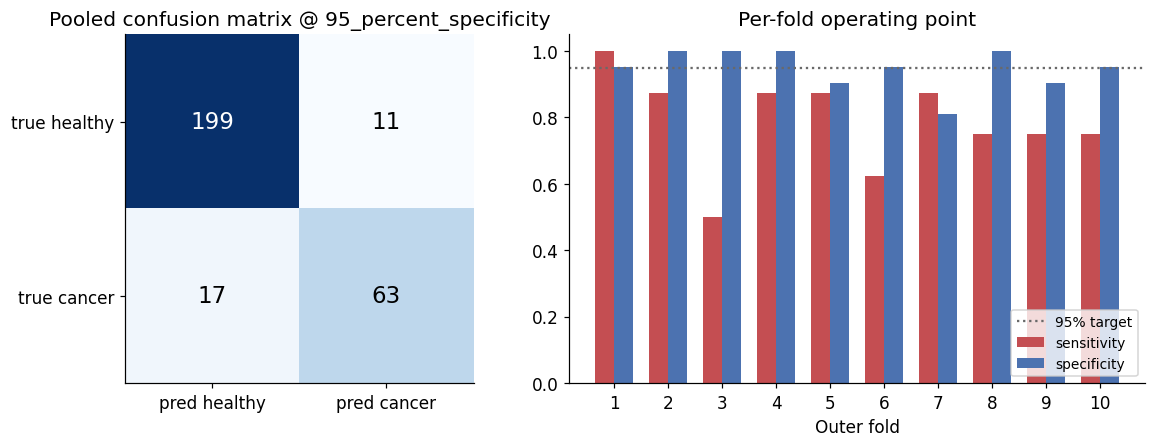

In [25]:
KEY = "95_percent_specificity"

rows = []
for _, r in per_fold.iterrows():
    rep = r["classification_report_full_model"][KEY]
    cm = np.array(r["confusion_matrix_full_model"][KEY], dtype=float)
    tn, fp, fn, tp = cm.ravel()
    thr = r["full_model_thresholds"]
    rows.append({
        "fold": r["fold"],
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": rep["1"]["precision"] if (tp + fp) > 0 else np.nan,
        "threshold": thr[KEY],
        "train_fpr_at_95spec": thr["train_fpr_at_95spec"],
    })
op = pd.DataFrame(rows)
print(op.to_string(index=False))
print(f"\nmean sensitivity {op['sensitivity'].mean():.3f} | "
      f"mean specificity {op['specificity'].mean():.3f} | "
      f"mean train FPR at the 95%-spec threshold {op['train_fpr_at_95spec'].mean():.3f} "
      f"(target 0.05)")

total_cm = np.zeros((2, 2))
for _, r in per_fold.iterrows():
    total_cm += np.array(r["confusion_matrix_full_model"][KEY], dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1, 1.3]})
ax1.imshow(total_cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{int(total_cm[i, j])}", ha="center", va="center",
                 fontsize=15, color="white" if total_cm[i, j] > total_cm.max() / 2 else "black")
ax1.set_xticks([0, 1], ["pred healthy", "pred cancer"])
ax1.set_yticks([0, 1], ["true healthy", "true cancer"])
ax1.set_title(f"Pooled confusion matrix @ {KEY}")

w = 0.35
ax2.bar(op["fold"] - w / 2, op["sensitivity"], w, label="sensitivity", color="#C44E52")
ax2.bar(op["fold"] + w / 2, op["specificity"], w, label="specificity", color="#4C72B0")
ax2.axhline(0.95, color="dimgray", ls=":", lw=1.5, label="95% target")
ax2.set_xticks(op["fold"]); ax2.set_xlabel("Outer fold"); ax2.set_ylim(0, 1.05)
ax2.set_title("Per-fold operating point")
ax2.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

## 7. Selected TSS indices — overlap across folds

Each fold ranks TSS regions inside its own training partition, so the selected sets differ.
Their overlap says how reproducible the gene selection is; a low overlap with a high AUC
means the signal is distributed rather than carried by a fixed handful of regions.

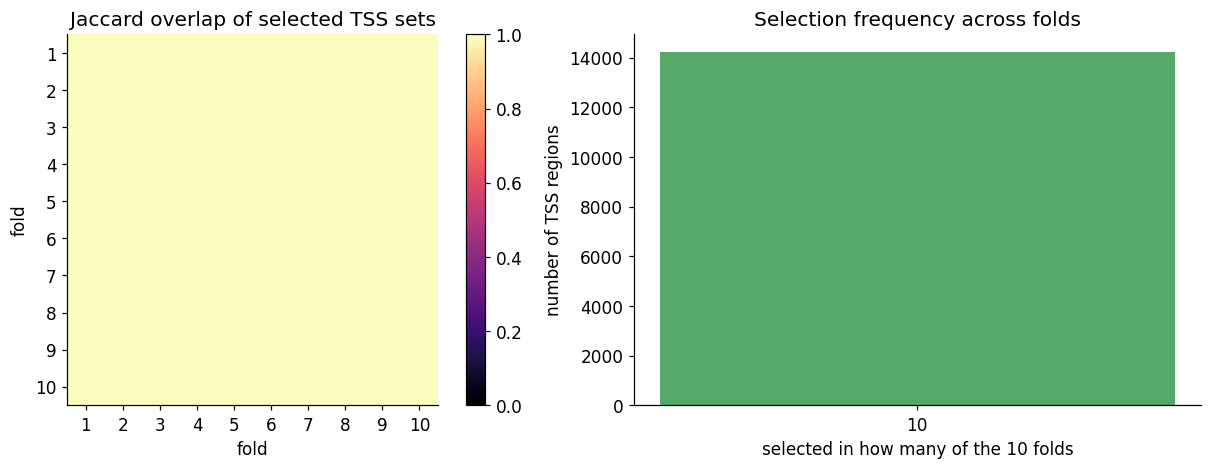

TSS regions selected in ALL 10 folds: 14219
TSS regions selected in at least one fold: 14219
Mean per-fold set size: 14219


In [26]:
sets = {f: set(idx) for f, idx in selected_indices.items()}
folds_sorted = sorted(sets)
n = len(folds_sorted)

jac = np.zeros((n, n))
for i, a in enumerate(folds_sorted):
    for j, b in enumerate(folds_sorted):
        union = sets[a] | sets[b]
        jac[i, j] = len(sets[a] & sets[b]) / len(union) if union else np.nan

from collections import Counter
counts = Counter()
for s in sets.values():
    counts.update(s)
n_folds_per_gene = Counter(counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
im = ax1.imshow(jac, cmap="magma", vmin=0, vmax=1)
ax1.set_xticks(range(n), folds_sorted); ax1.set_yticks(range(n), folds_sorted)
ax1.set_xlabel("fold"); ax1.set_ylabel("fold")
ax1.set_title("Jaccard overlap of selected TSS sets")
plt.colorbar(im, ax=ax1, fraction=0.046)

ks = sorted(n_folds_per_gene)
ax2.bar(ks, [n_folds_per_gene[k] for k in ks], color="#55A868")
ax2.set_xlabel("selected in how many of the 10 folds")
ax2.set_ylabel("number of TSS regions")
ax2.set_title("Selection frequency across folds")
ax2.set_xticks(ks)
plt.tight_layout()
plt.show()

core = [g for g, c in counts.items() if c == n]
print(f"TSS regions selected in ALL {n} folds: {len(core)}")
print(f"TSS regions selected in at least one fold: {len(counts)}")
print(f"Mean per-fold set size: {np.mean([len(s) for s in sets.values()]):.0f}")

## 8. Comparison with the fixed-configuration nested CV

`run_single_experiment` scores one fixed configuration per job; the best of those is
picked afterwards, on the same folds it is reported on. That number is optimistic by
construction. The gap below is the size of that optimism.

Set `FIXED_RESULTS_DIR` to a directory of `results_*.pkl` files to run this comparison.

Configurations compared      : 285
Best fixed config            : results_support_vector_machine_griffin_diff_15000_genes_mean_diff.pkl
  its mean CV AUC            : 0.9506   <- selected on these same folds
Fully nested mean held-out AUC: 0.9506
  difference (nested - fixed) : +0.0000


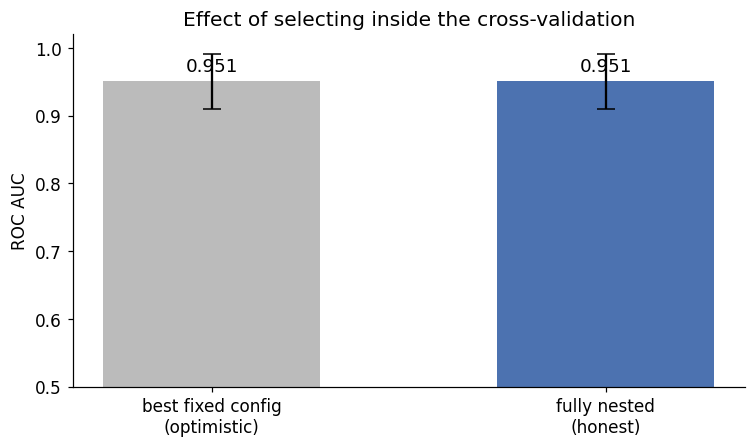

In [27]:
from glob import glob

FIXED_RESULTS_DIR = Path("nested_cv_results_cris/brca_crc_dd")

files = sorted(glob(str(FIXED_RESULTS_DIR / "results_*.pkl")))
if not files:
    print(f"No results_*.pkl in {FIXED_RESULTS_DIR} — skipping comparison.")
else:
    best = None
    for fp in files:
        with open(fp, "rb") as fh:
            df = pickle.load(fh)
        if "auc_full_model" not in df.columns or len(df) == 0:
            continue
        m = float(df["auc_full_model"].mean())
        if best is None or m > best[0]:
            best = (m, Path(fp).name, df)
    best_mean, best_name, best_df = best

    print(f"Configurations compared      : {len(files)}")
    print(f"Best fixed config            : {best_name}")
    print(f"  its mean CV AUC            : {best_mean:.4f}   <- selected on these same folds")
    print(f"Fully nested mean held-out AUC: {aucs.mean():.4f}")
    print(f"  difference (nested - fixed) : {aucs.mean() - best_mean:+.4f}")

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(["best fixed config\n(optimistic)", "fully nested\n(honest)"],
           [best_mean, aucs.mean()],
           yerr=[best_df["auc_full_model"].std(ddof=1), aucs.std(ddof=1)],
           color=["#BBBBBB", "#4C72B0"], capsize=6, width=0.55)
    ax.set_ylabel("ROC AUC"); ax.set_ylim(0.5, 1.02)
    ax.set_title("Effect of selecting inside the cross-validation")
    for i, v in enumerate([best_mean, aucs.mean()]):
        ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Does the trend over k survive de-biasing?

Figure 4a of the manuscript plots, for each k, the **best** AUROC over all configurations —
where each configuration's score is its mean across the ten outer folds. That maximum is
taken over scores computed on the very folds being reported, which is the step the reviewer
objects to. The question is whether the rise in AUROC with k is an artifact of that.

Two curves on the same data answer it, for the SVM / mean_diff slice that matches the
fully nested run:

* **Fig. 4a quantity** — at each k, `max` over features of the mean outer-fold AUROC.
* **De-biased (leave-one-fold-out)** — at each k, for every outer fold pick the feature using
  only the *other* nine folds, then score it on the held-out fold. No fold contributes to
  its own selection.

If the two curves have the same shape, the k trend is real and the post-hoc maximum only
shifts the level, not the story.

This cell reads the per-configuration pickles from the original run (60 files) — allow a
moment on a network share.

loaded 600 rows | 5 features | 12 k values | 10 outer folds


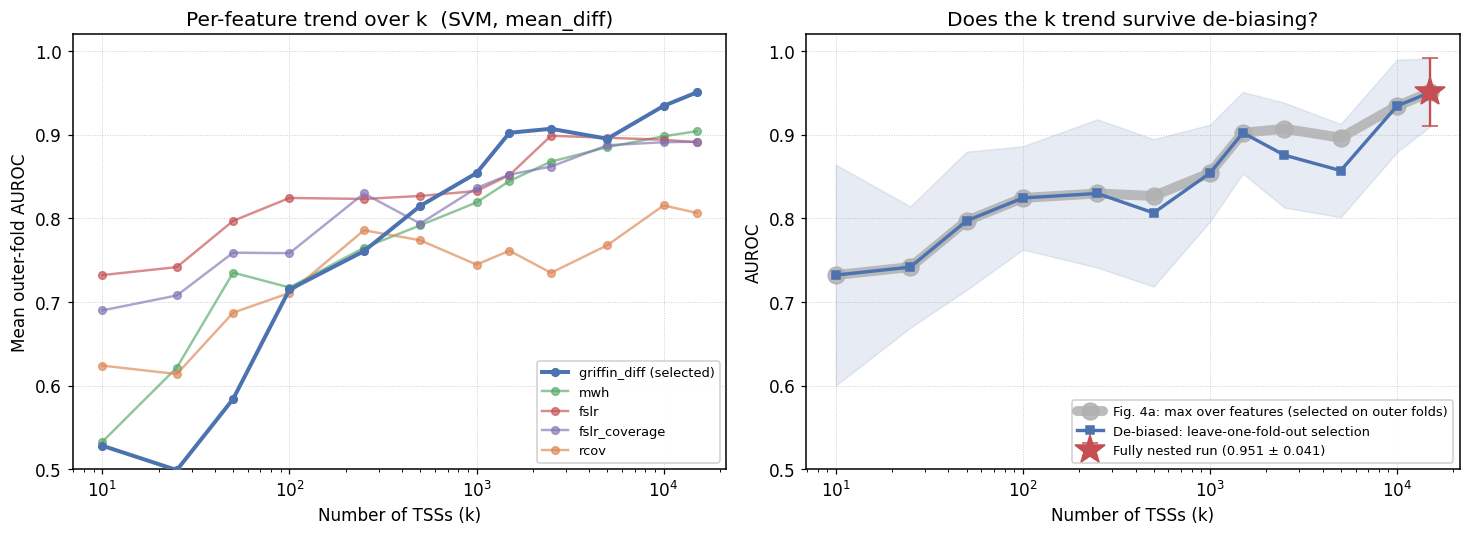

    k  fig4a_max  loo_debiased   delta
   10     0.7321        0.7321  0.0000
   25     0.7417        0.7417  0.0000
   50     0.7970        0.7970  0.0000
  100     0.8244        0.8244  0.0000
  250     0.8298        0.8298  0.0000
  500     0.8268        0.8065 -0.0202
 1000     0.8542        0.8542  0.0000
 1500     0.9024        0.9024  0.0000
 2500     0.9071        0.8756 -0.0315
 5000     0.8964        0.8571 -0.0393
10000     0.9345        0.9345  0.0000
15000     0.9506        0.9506  0.0000

k values where de-biasing changes nothing: 9/12
largest drop from de-biasing: -0.0393 (k=5000)
trend from smallest to largest k: 0.732 -> 0.951


In [28]:
from glob import glob

DD_DIR = Path("nested_cv_results_cris/brca_crc_dd")
KS = [10, 25, 50, 100, 250, 500, 1000, 1500, 2500, 5000, 10000, 15000]
FEATURES_K = ["fslr_coverage", "fslr", "griffin_diff", "rcov", "mwh"]

rows = []
for feat in FEATURES_K:
    for k in KS:
        hits = glob(str(DD_DIR / f"results_support_vector_machine_{feat}_{k}_genes_mean_diff.pkl"))
        if not hits:
            continue
        with open(hits[0], "rb") as fh:
            dfk = pickle.load(fh)
        for _, r in dfk.iterrows():
            rows.append({"feature": feat, "k": k,
                         "fold_id": tuple(sorted(r["test_sample_ids"])),
                         "auc": float(r["auc_full_model"])})

if not rows:
    raise FileNotFoundError(
        f"No per-configuration pickles found in {DD_DIR}. This cell compares against the "
        f"original run_single_experiment results; point DD_DIR at that directory."
    )

kd = pd.DataFrame(rows)
folds_k = list(dict.fromkeys(kd["fold_id"]))
lookup = {(r.feature, r.k, r.fold_id): r.auc for r in kd.itertuples()}
print(f"loaded {len(kd)} rows | {kd.feature.nunique()} features | {kd.k.nunique()} k values "
      f"| {len(folds_k)} outer folds")

# --- Curve 1: the Figure 4a quantity ---
per_cfg = kd.groupby(["feature", "k"])["auc"].mean().reset_index(name="mean_outer_auc")
fig4a = per_cfg.groupby("k")["mean_outer_auc"].max()

# --- Curve 2: de-biased by leave-one-fold-out selection at each k ---
loo_mean, loo_sd = {}, {}
for k in KS:
    pool = [f for f in FEATURES_K if all((f, k, g) in lookup for g in folds_k)]
    if not pool:
        continue
    held = []
    for f_out in folds_k:
        best_f = max(pool, key=lambda ft: np.mean(
            [lookup[(ft, k, g)] for g in folds_k if g != f_out]))
        held.append(lookup[(best_f, k, f_out)])
    loo_mean[k], loo_sd[k] = float(np.mean(held)), float(np.std(held, ddof=1))

ks_plot = sorted(loo_mean)

# Where the fully nested run landed (all folds agreed, so this is a single point)
nested_k = int(per_fold["n_top_genes"].iloc[0])
nested_auc = float(per_fold["test_auc"].mean())
nested_sd = float(per_fold["test_auc"].std(ddof=1))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5))

# ---------------- Panel A: per-feature curves (Figure 4a style, SVM slice) ----------------
for feat in sorted(FEATURES_K, key=lambda f:
                   -per_cfg.loc[per_cfg.feature == f, "mean_outer_auc"].max()):
    sub = per_cfg[per_cfg.feature == feat].sort_values("k")
    if sub.empty:
        continue
    is_winner = feat == per_fold["feature"].iloc[0]
    axA.plot(sub["k"], sub["mean_outer_auc"], marker="o", ms=5,
             lw=2.6 if is_winner else 1.6,
             color=FEATURE_COLORS.get(feat, "#999999"),
             alpha=1.0 if is_winner else 0.65,
             label=feat + (" (selected)" if is_winner else ""), zorder=3 if is_winner else 2)
axA.set_xscale("log")
axA.set_xlabel("Number of TSSs (k)")
axA.set_ylabel("Mean outer-fold AUROC")
axA.set_title("Per-feature trend over k  (SVM, mean_diff)")
axA.grid(True, which="major", ls=":", lw=0.6, color="0.7", alpha=0.7)
axA.set_axisbelow(True)
axA.legend(fontsize=8.5, loc="lower right", framealpha=0.92)

# ---------------- Panel B: biased vs de-biased envelope ----------------
# Drawn wide and underneath: where the two coincide the grey shows as a halo around
# the blue, so "no difference" is visible rather than hidden.
axB.plot(ks_plot, [fig4a[k] for k in ks_plot], marker="o", ms=11, lw=6.5,
         color="#B0B0B0", alpha=0.85, solid_capstyle="round", zorder=2,
         label="Fig. 4a: max over features (selected on outer folds)")

lm = np.array([loo_mean[k] for k in ks_plot])
ls = np.array([loo_sd[k] for k in ks_plot])
axB.plot(ks_plot, lm, marker="s", ms=5, lw=2.2, color="#4C72B0", zorder=4,
         label="De-biased: leave-one-fold-out selection")
axB.fill_between(ks_plot, lm - ls, lm + ls, color="#4C72B0", alpha=0.13)

axB.errorbar([nested_k], [nested_auc], yerr=[nested_sd], fmt="*", ms=20,
             color="#C44E52", capsize=5, zorder=6,
             label=f"Fully nested run ({nested_auc:.3f} ± {nested_sd:.3f})")

axB.set_xscale("log")
axB.set_xlabel("Number of TSSs (k)")
axB.set_ylabel("AUROC")
axB.set_title("Does the k trend survive de-biasing?")
axB.grid(True, which="major", ls=":", lw=0.6, color="0.7", alpha=0.7)
axB.set_axisbelow(True)
axB.legend(fontsize=8.5, loc="lower right", framealpha=0.92)

for ax in (axA, axB):
    ax.set_ylim(0.50, 1.02)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")

plt.tight_layout()
plt.show()

delta = pd.DataFrame({
    "k": ks_plot,
    "fig4a_max": [round(fig4a[k], 4) for k in ks_plot],
    "loo_debiased": [round(loo_mean[k], 4) for k in ks_plot],
    "delta": [round(loo_mean[k] - fig4a[k], 4) for k in ks_plot],
})
print(delta.to_string(index=False))
print(f"\nk values where de-biasing changes nothing: "
      f"{int((delta['delta'] == 0).sum())}/{len(delta)}")
print(f"largest drop from de-biasing: {delta['delta'].min():+.4f} "
      f"(k={int(delta.loc[delta['delta'].idxmin(), 'k'])})")
print(f"trend from smallest to largest k: "
      f"{delta['loo_debiased'].iloc[0]:.3f} -> {delta['loo_debiased'].iloc[-1]:.3f}")

## 10. The fully nested k trend

Section 9 de-biased the *selection* dimension but still read its numbers off the original
per-configuration run, where the TSS ranking was fitted on the whole outer-training
partition. At k < all that ranking is **not** inert, so those points still carry the step
the reviewer objects to. Only the k = all endpoint was fully clean.

This section uses `./submit_nested_full.sh ksweep`: one *complete* nested selection per k.
Feature, ranking function and the SVM hyperparameters are still chosen inside each fold's
inner CV, the ranking is refitted inside every inner-training partition, and only k is held
fixed. Every point on this curve is therefore leakage-free.

Three curves on one axis then separate the two effects: what the post-hoc maximum adds,
and what fitting the ranking inside the inner folds costs.

    k  mean_test_auc  std_test_auc  mean_inner_score  n_distinct_configs modal_feature modal_selection_type  mean_num_genes_used
   10       0.630952      0.181956          0.693144                   3          fslr            mean_diff                 10.0
   25       0.700595      0.093656          0.760472                   2          fslr            mean_diff                 25.0
   50       0.811310      0.079020          0.769929                   1          fslr            mean_diff                 50.0
  100       0.801190      0.105372          0.780335                   2          fslr            mean_diff                100.0
  250       0.786905      0.117844          0.801014                   3          fslr            mean_diff                250.0
  500       0.786310      0.116961          0.826962                   4  griffin_diff            mean_diff                500.0
 1000       0.826190      0.075803          0.853131                   3  griffin_diff           

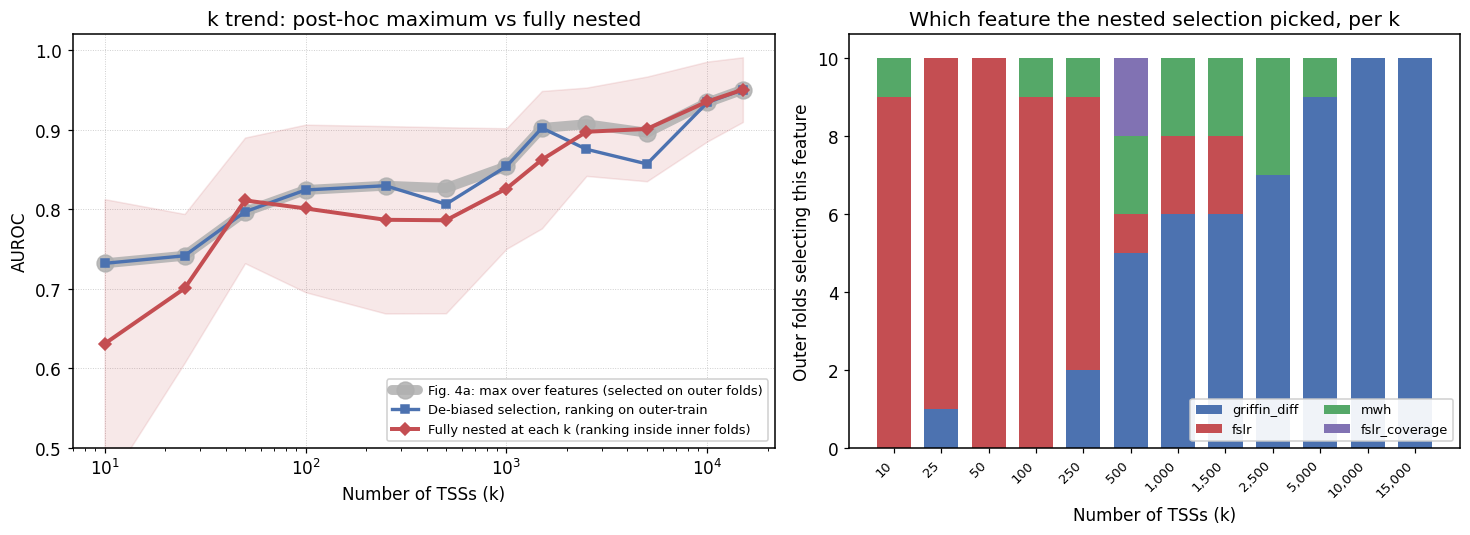


    k  fig4a_max  debiased_sel  fully_nested  nested_minus_fig4a  nested_minus_debiased
   10     0.7321        0.7321        0.6310             -0.1011                -0.1011
   25     0.7417        0.7417        0.7006             -0.0411                -0.0411
   50     0.7970        0.7970        0.8113              0.0143                 0.0143
  100     0.8244        0.8244        0.8012             -0.0232                -0.0232
  250     0.8298        0.8298        0.7869             -0.0429                -0.0429
  500     0.8268        0.8065        0.7863             -0.0405                -0.0202
 1000     0.8542        0.8542        0.8262             -0.0280                -0.0280
 1500     0.9024        0.9024        0.8625             -0.0399                -0.0399
 2500     0.9071        0.8756        0.8976             -0.0095                 0.0220
 5000     0.8964        0.8571        0.9012              0.0048                 0.0441
10000     0.9345        0.9345 

In [29]:
KSWEEP_DIR = Path("nested_cv_results_cris/nested_full_brca_crc_nested_full_ksweep")
sweep_path = KSWEEP_DIR / "nested_full_ksweep.csv"

if not sweep_path.exists():
    print(f"{sweep_path} not found.\nRun the sweep first:  ./submit_nested_full.sh ksweep")
else:
    sweep = pd.read_csv(sweep_path).sort_values("k").reset_index(drop=True)
    print(sweep[["k", "mean_test_auc", "std_test_auc", "mean_inner_score",
                 "n_distinct_configs", "modal_feature", "modal_selection_type",
                 "mean_num_genes_used"]].to_string(index=False))

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5),
                                   gridspec_kw={"width_ratios": [1.15, 1]})

    # ---------------- Panel A: the three curves ----------------
    have_s9 = "fig4a" in globals() and "loo_mean" in globals()
    if have_s9:
        ks9 = sorted(loo_mean)
        axA.plot(ks9, [fig4a[k] for k in ks9], marker="o", ms=11, lw=6.5,
                 color="#B0B0B0", alpha=0.85, solid_capstyle="round", zorder=2,
                 label="Fig. 4a: max over features (selected on outer folds)")
        axA.plot(ks9, [loo_mean[k] for k in ks9], marker="s", ms=5, lw=2.2,
                 color="#4C72B0", zorder=3,
                 label="De-biased selection, ranking on outer-train")
    else:
        print("\n(run section 9 first to overlay the two comparison curves)")

    m = sweep["mean_test_auc"].to_numpy()
    s = sweep["std_test_auc"].to_numpy()
    axA.plot(sweep["k"], m, marker="D", ms=6, lw=2.6, color="#C44E52", zorder=5,
             label="Fully nested at each k (ranking inside inner folds)")
    axA.fill_between(sweep["k"], m - s, m + s, color="#C44E52", alpha=0.13, zorder=1)

    axA.set_xscale("log")
    axA.set_xlabel("Number of TSSs (k)")
    axA.set_ylabel("AUROC")
    axA.set_ylim(0.50, 1.02)
    axA.set_title("k trend: post-hoc maximum vs fully nested")
    axA.grid(True, which="major", ls=":", lw=0.6, color="0.7", alpha=0.7)
    axA.set_axisbelow(True)
    axA.legend(fontsize=8.5, loc="lower right", framealpha=0.92)

    # ---------------- Panel B: which feature won at each k ----------------
    votes = {}
    for _, r in sweep.iterrows():
        d = {}
        for part in str(r["feature_votes"]).split(";"):
            if "=" in part:
                name, n = part.rsplit("=", 1)
                d[name.strip()] = int(n)
        votes[int(r["k"])] = d
    feats_seen = sorted({f for d in votes.values() for f in d},
                        key=lambda f: -sum(votes[k].get(f, 0) for k in votes))

    ks_sorted = sorted(votes)
    xpos = np.arange(len(ks_sorted))
    bottom = np.zeros(len(ks_sorted))
    for feat in feats_seen:
        vals = np.array([votes[k].get(feat, 0) for k in ks_sorted], dtype=float)
        axB.bar(xpos, vals, bottom=bottom, width=0.72,
                color=FEATURE_COLORS.get(feat, "#999999"), label=feat)
        bottom += vals
    axB.set_xticks(xpos)
    axB.set_xticklabels([f"{k:,}" for k in ks_sorted], rotation=45, ha="right", fontsize=8.5)
    axB.set_xlabel("Number of TSSs (k)")
    axB.set_ylabel("Outer folds selecting this feature")
    axB.set_ylim(0, 10.6)
    axB.set_title("Which feature the nested selection picked, per k")
    axB.legend(fontsize=8.5, loc="lower right", ncol=2, framealpha=0.92)

    for ax in (axA, axB):
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")

    plt.tight_layout()
    plt.show()

    if have_s9:
        cmp = pd.DataFrame({
            "k": sweep["k"],
            "fig4a_max": [round(float(fig4a[k]), 4) for k in sweep["k"]],
            "debiased_sel": [round(float(loo_mean[k]), 4) for k in sweep["k"]],
            "fully_nested": sweep["mean_test_auc"].round(4),
        })
        cmp["nested_minus_fig4a"] = (cmp["fully_nested"] - cmp["fig4a_max"]).round(4)
        cmp["nested_minus_debiased"] = (cmp["fully_nested"] - cmp["debiased_sel"]).round(4)
        print("\n" + cmp.to_string(index=False))
        print(f"\nmean gap, fully nested - Fig. 4a max      : "
              f"{cmp['nested_minus_fig4a'].mean():+.4f}")
        print(f"mean gap, fully nested - de-biased select : "
              f"{cmp['nested_minus_debiased'].mean():+.4f}")
        print("\nThe first gap is what the post-hoc maximum plus outer-fold ranking add "
              "together;\nthe second isolates what refitting the ranking inside the inner "
              "folds costs.")